
# Redimensionamento de Imagens com OpenCV

## Conceitos Fundamentais

**Resolução e Proporção de Tela (*Aspect Ratio*)**

* Toda imagem digital é uma matriz de pixels de dimensões $\text{Largura} \times \text{Altura}$.
* Ao redimensionar uma imagem, alterar a largura e a altura sem manter a proporção original faz com que a imagem fique visivelmente esticada ou achatada.

**Interpolação (*Interpolation*)**

* Ao redimensionar uma imagem, o algoritmo precisa calcular a cor e o valor dos novos pixels criados (*upscaling*) ou combinados/removidos (*downscaling*).
* **`cv2.INTER_LINEAR` (Interpolação Bilinear):** É o método padrão do OpenCV. Funciona muito bem para redimensionamento geral por oferecer um bom equilíbrio entre qualidade visual e velocidade de processamento.
* **Escolhas por cenário:**
* **Para *Downscaling* (Redução):** O método `cv2.INTER_AREA` é o mais recomendado, pois evita efeitos de serrilhado (*aliasing*).
* **Para *Upscaling* (Ampliação):** Para obter maior qualidade visual, costuma-se utilizar `cv2.INTER_CUBIC` ou `cv2.INTER_LANCZOS4`.



**Espaço de Cores BGR**

* O OpenCV representa imagens como matrizes NumPy no formato **BGR** (Azul, Verde, Vermelho), e não no padrão **RGB** (Vermelho, Verde, Azul) mais comum em outras bibliotecas.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving image.jpg to image.jpg


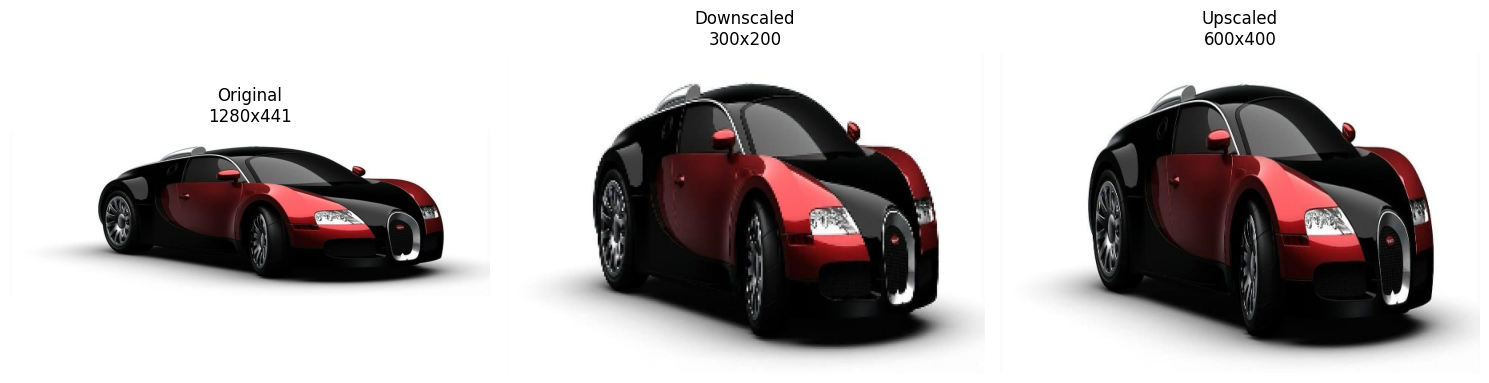

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregue a imagem (certifique-se de fazer o upload do arquivo 'image.jpg' no Colab)
image = cv2.imread('image.jpg')

# O OpenCV lê em BGR, mas o Matplotlib exibe em RGB. É preciso converter:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Redimensionando para baixo (Downscaling)
down_width = 300
down_height = 200
down_points = (down_width, down_height)
resized_down = cv2.resize(image_rgb, down_points, interpolation=cv2.INTER_LINEAR)

# 3. Redimensionando para cima (Upscaling)
up_width = 600
up_height = 400
up_points = (up_width, up_height)
resized_up = cv2.resize(image_rgb, up_points, interpolation=cv2.INTER_LINEAR)

# 4. Exibindo as imagens lado a lado usando Matplotlib
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title(f'Original\n{image.shape[1]}x{image.shape[0]}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(resized_down)
plt.title(f'Downscaled\n{down_width}x{down_height}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(resized_up)
plt.title(f'Upscaled\n{up_width}x{up_height}')
plt.axis('off')

plt.tight_layout()
plt.show()

Eixo de Concatenação ( axis) :

axis = 0: Empilha como imagens uma abaixo da outra ( Vertical ).

axis = 1: Coloca as imagens lado a lado ( Horizontal ). Atenção: o comentário no seu código dizia "eixo horizontal", mas axis=0faz o empilhamento vertical.

Requisito donp.concatenate : Para concatenar imagens com np.concatenate, todos devem ter exatamente as mesmas dimensões (mesma largura para empilhar na vertical, ou mesma altura para empilhar na horizontal) e o mesmo número de canais de cor.

Alteração para o Colab : A linha cv2.imshow('Inter Nearest :: Inter Linear :: Inter Area', vertical)foi substituída por cv2_imshow(vertical)para evitar erros de ambiente sem interface gráfica na nuvem.

Comparação Vertical: INTER_NEAREST | INTER_LINEAR | INTER_AREA


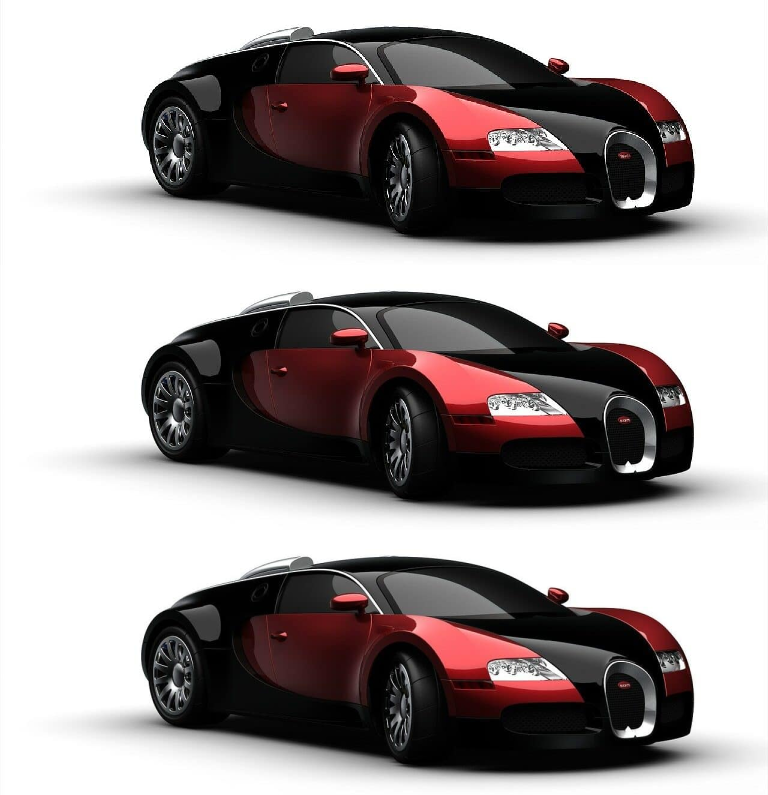

In [5]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Carregar a imagem
image = cv2.imread('image.jpg')

# 2. Definir a variável de escala (redução para 60% do tamanho)
scale_down = 0.6

# 3. Redimensionar usando diferentes métodos de interpolação
res_inter_nearest = cv2.resize(image, None, fx=scale_down, fy=scale_down, interpolation=cv2.INTER_NEAREST)
res_inter_linear  = cv2.resize(image, None, fx=scale_down, fy=scale_down, interpolation=cv2.INTER_LINEAR)
res_inter_area    = cv2.resize(image, None, fx=scale_down, fy=scale_down, interpolation=cv2.INTER_AREA)

# 4. Concatenar as imagens no eixo vertical (axis=0) para comparação
vertical = np.concatenate((res_inter_nearest, res_inter_linear, res_inter_area), axis=0)

# 5. Exibir a imagem concatenada no Colab
print("Comparação Vertical: INTER_NEAREST | INTER_LINEAR | INTER_AREA")
cv2_imshow(vertical)


### Redimensionamento Inteligente (`resize_to_fit`)

Esta função ajusta o tamanho de uma imagem para caber em uma dimensão máxima sem distorcer o conteúdo ou perder qualidade.

* Manutenção de Proporção: Usa o menor fator de escala entre largura e altura (`min`), garantindo que a imagem caiba no limite sem ser esticada ou cortada.
* Proteção de Qualidade (`allow_upscale=False`): Evita ampliar imagens pequenas, o que causaria perda de nitidez.
* Segurança na Dimensão: Arredonda o tamanho para inteiros válidos e usa `max(1, ...)` para evitar imagens com $0$ pixels.
* Interpolação Automática: Aplica `cv2.INTER_AREA` para reduções (*downscaling*) e `cv2.INTER_CUBIC` para ampliações (*upscaling*).
* Retorno Útil: Devolve a imagem ajustada e o fator de escala aplicado (útil para reajustar caixas de detecção/bounding boxes).

Escala aplicada: 0.31
Tamanho original: 1280x441
Novo tamanho: 400x138


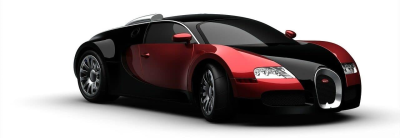

In [6]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def resize_to_fit(image, max_width, max_height, allow_upscale=False):
    """
    Redimensiona uma imagem para caber dentro de max_width x max_height
    mantendo a proporção original (Aspect Ratio).
    """
    # 1. Validação de segurança
    if image is None or image.size == 0:
        raise ValueError("image must be non-empty")

    # 2. Obtém a altura e largura atuais da imagem
    height, width = image.shape[:2]

    # 3. Calcula a escala necessária para ambos os eixos e pega a MENOR
    scale = min(max_width / width, max_height / height)

    # 4. Se não for permitido ampliar (allow_upscale=False), limita a escala a no máximo 1.0 (100%)
    if not allow_upscale:
        scale = min(scale, 1.0)

    # 5. Calcula as novas dimensões em pixels (com arredondamento de +0.5 para precisão)
    target = (
        max(1, int(width * scale + 0.5)),
        max(1, int(height * scale + 0.5)),
    )

    # 6. Escolha inteligente da interpolação: AREA para redução, CUBIC para ampliação
    method = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC

    # 7. Retorna a imagem redimensionada e o fator de escala aplicado
    return cv2.resize(image, target, interpolation=method), scale

# ==========================================
# EXEMPLO DE USO NO GOOGLE COLAB
# ==========================================
image = cv2.imread('image.jpg')

# Tenta encaixar a imagem em um limite de 400x300 pixels
resized_img, scale_used = resize_to_fit(image, max_width=400, max_height=300)

print(f"Escala aplicada: {scale_used:.2f}")
print(f"Tamanho original: {image.shape[1]}x{image.shape[0]}")
print(f"Novo tamanho: {resized_img.shape[1]}x{resized_img.shape[0]}")

# Exibe o resultado
cv2_imshow(resized_img)

### Preenchimento e Centralização (*Letterboxing*)

Esta etapa garante que a imagem final tenha **exatamente** a largura e altura desejadas, preenchendo as sobras das bordas com uma cor neutra.

* Chamada da Função: Redimensiona a imagem usando o limite `(target_width, target_height)` com `allow_upscale=True` para permitir a ampliação se a imagem for menor que o alvo.
* Criação da Tela de Fundo (`np.full`): Cria uma matriz com a dimensão exata solicitada e preenche o fundo com uma cor cinza-escura (valor `BGR = (32, 32, 32)`).
* Cálculo de Deslocamento (`offset_x`, `offset_y`): Descobre o espaço que sobrou nas laterais ou no topo/base e divide por 2 para encontrar o ponto central exato.
* Inserção por *Slicing*: Sobrepõe a imagem redimensionada exatamente no centro do fundo cinza usando indexação do NumPy.

--- Imagem com Letterboxing (Centralizada com Moldura) ---


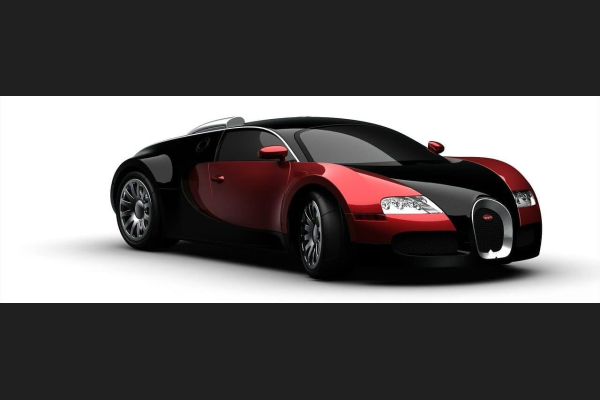

In [7]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. Função de redimensionamento proporcional
def resize_to_fit(image, max_width, max_height, allow_upscale=False):
    if image is None or image.size == 0:
        raise ValueError("image must be non-empty")
    height, width = image.shape[:2]
    scale = min(max_width / width, max_height / height)
    if not allow_upscale:
        scale = min(scale, 1.0)

    target = (
        max(1, int(width * scale + 0.5)),
        max(1, int(height * scale + 0.5)),
    )
    method = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_CUBIC
    return cv2.resize(image, target, interpolation=method), scale

# 2. Carregar a imagem (certifique-se de ter enviado 'image.jpg' para o Colab)
image = cv2.imread('image.jpg')

# 3. Definir o tamanho final exato desejado (quadro/canvas)
target_width = 600
target_height = 400

# 4. Redimensionar a imagem mantendo a proporção
resized, scale = resize_to_fit(
    image,
    target_width,
    target_height,
    allow_upscale=True,
)

# 5. Criar a tela de fundo cinza-escura (32, 32, 32) nas dimensões exatas
output = np.full(
    (target_height, target_width, 3),
    (32, 32, 32),
    dtype=image.dtype,
)

# 6. Calcular a posição para centralizar a imagem no fundo
offset_x = (target_width - resized.shape[1]) // 2
offset_y = (target_height - resized.shape[0]) // 2

# 7. Inserir a imagem no centro do fundo
output[
    offset_y:offset_y + resized.shape[0],
    offset_x:offset_x + resized.shape[1],
] = resized

# 8. Exibir a imagem resultante no Google Colab
print("--- Imagem com Letterboxing (Centralizada com Moldura) ---")
cv2_imshow(output)